# FEM for submerged tunnel as 3D beams

In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

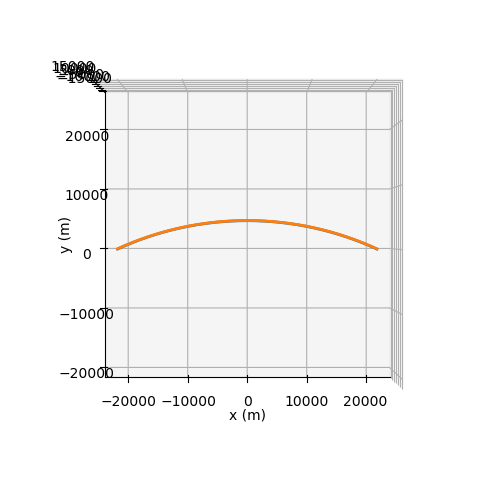

In [ ]:
TunRad = 50000 #m
TunAng = (114.65, 65.35) #deg
node_spacing = 54.0  

angle_start = np.deg2rad(TunAng[0])
angle_end = np.deg2rad(TunAng[1])
angle_step = node_spacing / TunRad
angles = np.arange(angle_start, angle_end - angle_step, -angle_step)

TunCX = TunRad*np.cos(angles)
TunCY = TunRad*np.sin(angles)
TunCZ = np.zeros_like(TunCX)

outerOffset = 30
TunRad2 = TunRad + outerOffset
TunCX2 = TunRad2*np.cos(angles)
TunCY2 = TunRad2*np.sin(angles)
TunCZ2 = np.zeros_like(TunCX2)

shiftY = -min(np.concatenate([TunCY, TunCY2])) + 5
TunCY += shiftY
TunCY2 += shiftY

ax = plt.axes(projection='3d')
ax.view_init(90, 270)
plt.plot(TunCX, TunCY, TunCZ, lw=2)
plt.plot(TunCX2, TunCY2, TunCZ2, lw=2)
plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')

TunCX = np.append(TunCX, TunCX2)
TunCY = np.append(TunCY, TunCY2)
TunCZ = np.append(TunCZ, TunCZ2)

## Properties of Beam

In [3]:
E = 36.0e9            
nu = 0.2      
rho_w = 1025
rho_c = 2650
g = 9.81
#tunnel
D_out = 20 #m  
D_in = 18 #m
dist_c2c = 30.0 #m
A_beton = (np.pi / 4) * (D_out**2 - D_in**2)
I_beam = (np.pi / 64) * (D_out**4 - D_in**4) 

#connectie
D_out_conn = 6.0; D_in_conn = 5.0; L_conn = 10.0
A_beton_conn = (np.pi / 4) * (D_out_conn**2 - D_in_conn**2)
I_beton_conn = (np.pi / 64) * (D_out_conn**4 - D_in_conn**4)


In [4]:
Beam_m =  A_beton * rho_c + 749.0e3 / g               # [kg/m]
Beam_EI = E * I_beam               # [N.m2]
Beam_EA = E * A_beton              # [N]
Beam_G = E / (2 * (1 + nu))
Beam_J = 0.623 * ((D_out /2) ** 4)
Beam_GJ = Beam_G * Beam_J            # [N.m2]
Beam_Im = rho_c * Beam_J          #[kg.m]

In [5]:
conn_m = A_beton_conn * rho_c         
conn_EI = E * I_beton_conn
conn_EA = E * A_beton_conn

conn_G = E / (2 * (1 + nu))
conn_J = 0.623 * ((D_out_conn / 2) ** 4)
conn_GJ = conn_G * conn_J            
conn_Im = rho_c * conn_J

## Mesh setup

In [ ]:
NodeC = [ [x,y,z] for x,y,z in zip(TunCX, TunCY, TunCZ) ]
nNode = len(NodeC)
nNodeTunnel = int(nNode/2)

def get_total_tube_mass_per_meter(node_index):
  
    x_pos_meter = node_index * node_spacing
    x_km = x_pos_meter / 1000.0
    
    if 0.0 <= x_km < 8.0: 
        F_ballast = 2425.33
    elif 8.0 <= x_km < 23.0: 
        F_ballast = 2408.77
    elif 23.0 <= x_km < 28.0: 
        F_ballast = 2352.75
    elif 28.0 <= x_km < 38.0: 
        F_ballast = 2405.78
    else: 
        F_ballast = 2424.70
        
    m_ballast = (F_ballast * 1000.0) / g
    
    A_buiten = (np.pi / 4) * (D_out**2)
    C_a_theory = 1.0
    added_mass_tube = rho_w * A_buiten * C_a_theory
    
    m_tot_meter = (A_beton * rho_c) + ((749.0e3 / g) / 2) + (m_ballast / 2) + added_mass_tube
    return m_tot_meter

def vind_lokale_mooring_stijfheid(x_pos_meter):

    x_km = x_pos_meter / 1000.0

    if 0.0 <= x_km < 8.0:
        # 35
        Kxx = 598.58 
        Kyy = 3169.06  
        Kzz = 2788.59 
        Kxy = 0
        Kxz = 0
        Kyz = 329.4
        
    elif 8.0 <= x_km < 23.0:
        # 85
        Kxx = 4.37
        Kyy = 286.96 
        Kzz = 31.44
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 64.72
        
    elif 23.0 <= x_km < 28.0:
        Kxx = 8.54
        Kyy = 290.61
        Kzz = 35.4
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 31.73
        
    elif 28.0 <= x_km < 38.0:
        #95
        Kxx = 5.02
        Kyy = 253.27
        Kzz = 38.5
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 45.69
        
    else:
        # 25
        Kxx = 1142.26
        Kyy = 4681.8
        Kzz = 4139.6
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 632.57
        
    return Kxx*1000, Kyy*1000, Kzz*1000, Kxy*1000, Kxz*1000, Kyz*1000



In [ ]:
Ele = []

for i in range(0, nNodeTunnel - 1):
    m_dynamisch = get_total_tube_mass_per_meter(2*i)
    Ele.append([int(i), int(i + 1), m_dynamisch, Beam_EA, Beam_EI, Beam_GJ, Beam_Im])

for i in range(0, nNodeTunnel - 1):
    n1 = i + nNodeTunnel
    n2 = n1 + 1
    m_dynamisch = get_total_tube_mass_per_meter(2*i)
    Ele.append([int(n1), int(n2), m_dynamisch, Beam_EA, Beam_EI, Beam_GJ, Beam_Im])

connector_interval = 8
for i in range(0, nNodeTunnel, connector_interval):
    n1 = i
    n2 = i + nNodeTunnel
    if n2 < nNode:
        Ele.append([int(n1), int(n2), conn_m, conn_EA, conn_EI, conn_GJ, conn_Im])

nEle = len(Ele)

print(f"Totaal aantal knopen (nNode): {nNode}")
print(f"Totaal aantal elementen (nEle) inclusief connectoren: {nEle}")
connectoren_gevonden = 0
for el in Ele:
    if int(round(el[1])) - int(round(el[0])) == nNodeTunnel:
        connectoren_gevonden += 1

print(f"Aantal actieve connectoren in de elementenlijst: {connectoren_gevonden}")

Totaal aantal knopen (nNode): 1596
Totaal aantal elementen (nEle) inclusief connectoren: 1694
Aantal actieve connectoren in de elementenlijst: 100


Listing the nodes and elements. <br>
Plot the mesh setup for reference.

Nodes
Elements


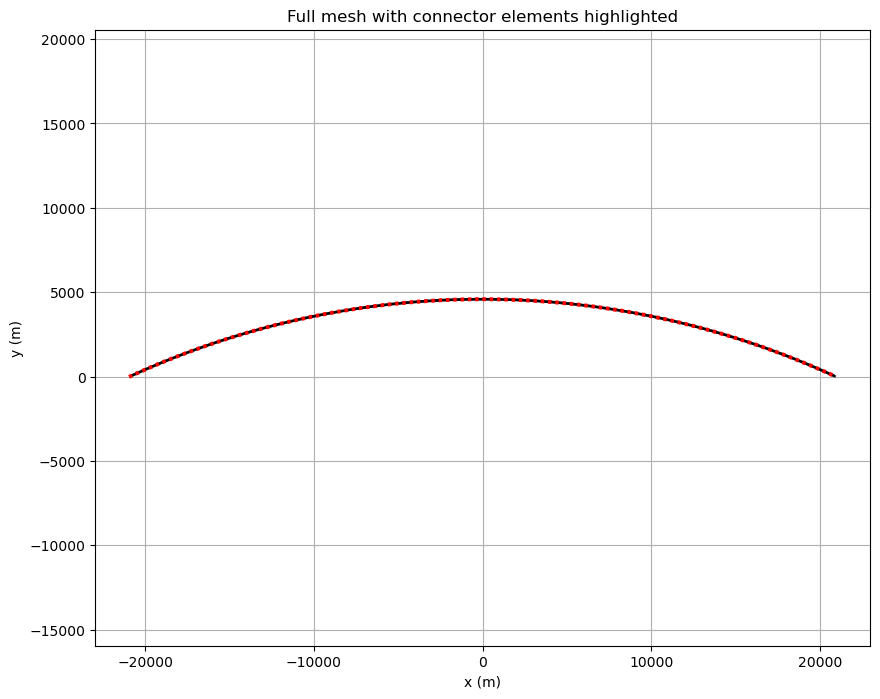

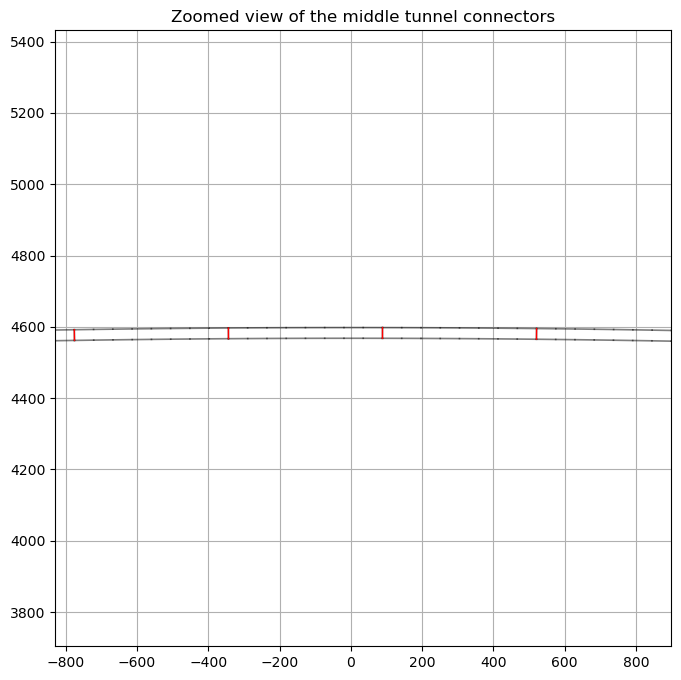

In [ ]:
print("Nodes")

NodeC_arr = np.array(NodeC)

plt.figure(figsize=(10, 8))
print("Elements")
for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    plt.plot([NodeC[n1][0], NodeC[n2][0]],
             [NodeC[n1][1], NodeC[n2][1]],
             lw=1.5, color='k', alpha=0.5)

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    if abs(n2 - n1) > 1: 
        plt.plot([NodeC_arr[n1,0], NodeC_arr[n2,0]],
                 [NodeC_arr[n1,1], NodeC_arr[n2,1]],
                 lw=2.5, color='red')

plt.grid(True)
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Full mesh with connector elements highlighted')

center_index = nNodeTunnel // 2
x_center = NodeC_arr[center_index, 0]
y_center = NodeC_arr[center_index, 1]
span = 1000

fig, ax = plt.subplots(figsize=(10, 8))

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    ax.plot([NodeC[n1][0], NodeC[n2][0]],
            [NodeC[n1][1], NodeC[n2][1]],
            lw=1.2, color='k', alpha=0.5)

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    if abs(n2 - n1) > 1:
        ax.plot([NodeC_arr[n1,0], NodeC_arr[n2,0]],
                [NodeC_arr[n1,1], NodeC_arr[n2,1]],
                lw=1, color='red')

span = 864 # (16 nodes * 54m)
ax.set_xlim(x_center - span, x_center + span)
ax.set_ylim(y_center - span, y_center + span)

ax.set_aspect('equal')
ax.grid(True)
ax.set_title('Zoomed view of the middle tunnel connectors')
pass

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [ ]:
import time
import numpy as np
from BeamMatrices import Beam3DMatrices

LDOF = 6
nDof = LDOF * nNode  # 6 dof per node

K = np.zeros(nDof * nDof)
M = np.zeros(nDof * nDof)
Q = np.zeros(nDof * nDof)

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(0, nEle):
    n1 = int(round(Ele[iEle][0]))
    n2 = int(round(Ele[iEle][1]))
    
    n1dof = LDOF * n1 + np.arange(0, LDOF)
    n2dof = LDOF * n2 + np.arange(0, LDOF)    
    indexes = np.append(n1dof, n2dof)
    
   
    Me, Ke, Qe = Beam3DMatrices(Ele[iEle][2], Ele[iEle][3], Ele[iEle][4], Ele[iEle][5], Ele[iEle][6], (NodeC[n1], NodeC[n2]))
    
    if (n2 - n1) == nNodeTunnel:  
        dx = NodeC[n2][0] - NodeC[n1][0]
        dy = NodeC[n2][1] - NodeC[n1][1]
        L = np.sqrt(dx**2 + dy**2)
        
        cx = dx / L
        cy = dy / L
        
        T_corr = np.array([[-cy, cx, 0], 
                           [-cx, -cy, 0], 
                           [0, 0, 1]])
        
        T_element = np.zeros((12, 12))
        for i_block in range(4):
            T_element[i_block*3:(i_block+1)*3, i_block*3:(i_block+1)*3] = T_corr
            
        Ke = T_element.T @ Ke @ T_element
        Me = T_element.T @ Me @ T_element
        Qe = T_element.T @ Qe @ T_element

    for i in range(0, 2 * LDOF):
        for j in range(0, 2 * LDOF):
            ij = indexes[i] * nDof + indexes[j]
            M[ij] = M[ij] + Me[i, j]
            K[ij] = K[ij] + Ke[i, j]
            Q[ij] = Q[ij] + Qe[i, j]

M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))

for i in range(0, nNodeTunnel):
    x_pos_k1 = i * node_spacing  
    Kxx_k1, Kyy_k1, Kzz_k1, Kxy_k1, Kxz_k1, Kyz_k1 = vind_lokale_mooring_stijfheid(x_pos_k1)
    
    dof_x_k1 = i * LDOF + 0  # Axiaal (X)
    dof_y_k1 = i * LDOF + 1  # Transversaal (Y)
    dof_z_k1 = i * LDOF + 2  # Verticaal (Z)
    
    K[dof_x_k1, dof_x_k1] += Kxx_k1
    K[dof_y_k1, dof_y_k1] += Kyy_k1
    K[dof_z_k1, dof_z_k1] += Kzz_k1
    
    K[dof_x_k1, dof_y_k1] += Kxy_k1
    K[dof_y_k1, dof_x_k1] += Kxy_k1
    K[dof_x_k1, dof_z_k1] += Kxz_k1
    K[dof_z_k1, dof_x_k1] += Kxz_k1
    K[dof_y_k1, dof_z_k1] += Kyz_k1
    K[dof_z_k1, dof_y_k1] += Kyz_k1
    
    n_k2 = i 
    x_pos_k2 = NodeC[n_k2][0]
    Kxx_k2, Kyy_k2, Kzz_k2, Kxy_k2, Kxz_k2, Kyz_k2 = vind_lokale_mooring_stijfheid(x_pos_k1)
    
    dof_x_k2 = n_k2 * LDOF + 0  # Axiaal (X)
    dof_y_k2 = n_k2 * LDOF + 1  # Transversaal (Y)
    dof_z_k2 = n_k2 * LDOF + 2  # Verticaal (Z)
    
    K[dof_x_k2, dof_x_k2] += Kxx_k2
    K[dof_y_k2, dof_y_k2] += Kyy_k2
    K[dof_z_k2, dof_z_k2] += Kzz_k2
    
    K[dof_x_k2, dof_y_k2] += Kxy_k2
    K[dof_y_k2, dof_x_k2] += Kxy_k2
    K[dof_x_k2, dof_z_k2] += Kxz_k2
    K[dof_z_k2, dof_x_k2] += Kxz_k2
    K[dof_y_k2, dof_z_k2] += Kyz_k2
    K[dof_z_k2, dof_y_k2] += Kyz_k2

exeTime[1] = time.time()
print("Handmatige assemblage succesvol voltooid!")
print("Execution time = {:.4f} s".format(exeTime[1] - exeTime[0]))

Handmatige assemblage succesvol voltooid!
Execution time = 0.9630 s


## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

[   0    1    2    3    4    5 4782 4783 4784 4785 4786 4787 4788 4789
 4790 4791 4792 4793 9570 9571 9572 9573 9574 9575]
[   6    7    8 ... 9567 9568 9569]


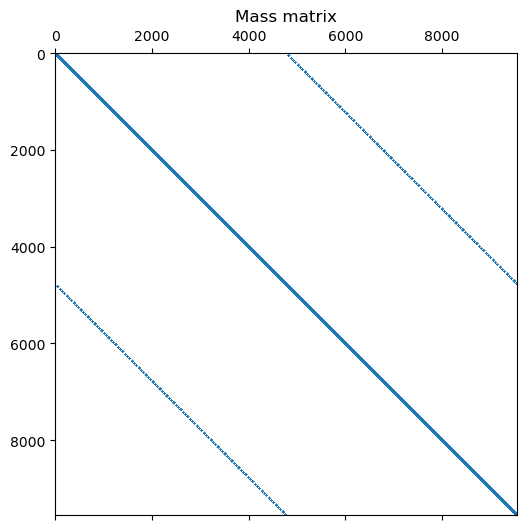

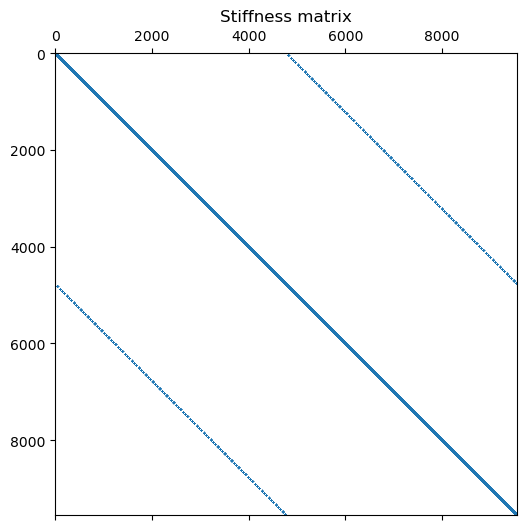

In [ ]:
NodesClamp = (0, int(round(nNode/2-1)), int(round(nNode/2)), nNode-1)

# Prescribed dofs
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Free dofs
DofsF = np.arange(0, nDof)       
DofsF = np.delete(DofsF, DofsP)  

print(DofsP)
print(DofsF)

M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

plt.figure()
plt.spy(M_FF, markersize=0.2)
plt.title("Mass matrix")
plt.figure()
plt.spy(K_FF, markersize=0.2)
plt.title("Stiffness matrix")
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [11]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat)
w = np.sqrt(w2.real)
f = w/2/np.pi
print(len(f))

9552


C:\Users\nienk\AppData\Local\Temp\ipykernel_11724\367166604.py:3: RuntimeWarning: invalid value encountered in sqrt
  w = np.sqrt(w2.real)


In [12]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

print(f)

[3.58694516e-05 6.97304554e-05 1.04008624e-04 ...            nan
            nan            nan]


In [13]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr

9552


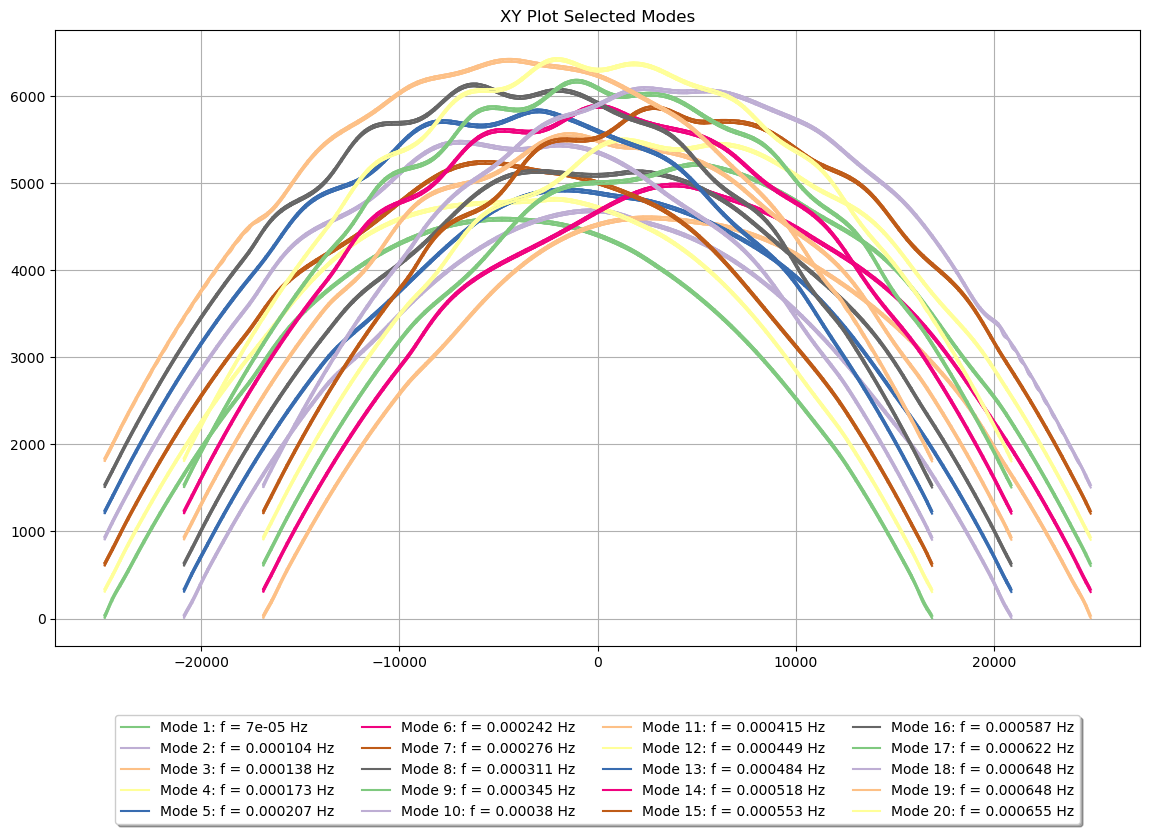

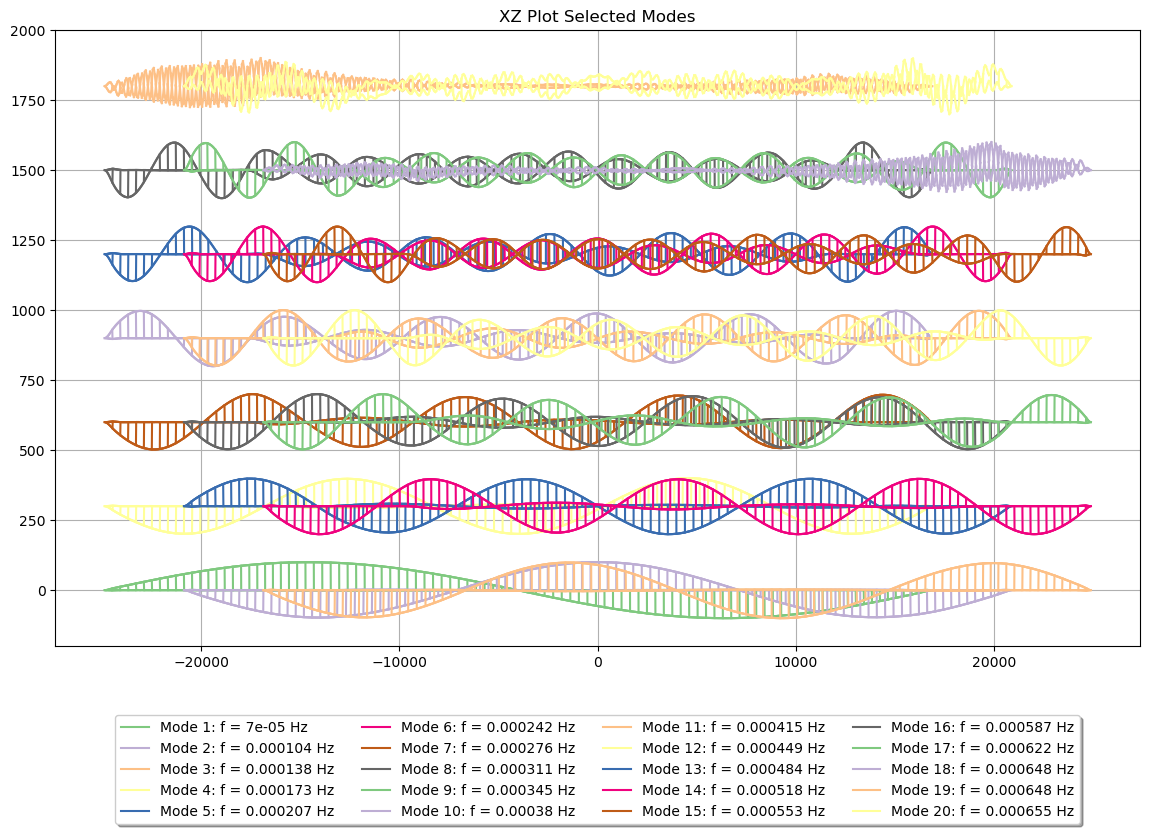

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

important_modes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

plt.figure(figsize=(14, 8))
cmap = plt.colormaps.get_cmap('Accent')
cmap = cmap.colors
nCmap = len(cmap)

def plotEle(DisplacedNode, idx, iMode):
    for iElem in np.arange(0, nEle):
        NodeLeft = int(round(Ele[iElem][0]))
        NodeRight = int(round(Ele[iElem][1]))
        if(iElem == 0):
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[idx % nCmap], 
                     label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
        else:
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[idx % nCmap])

# XY Plot
for idx, iMode in enumerate(important_modes):    
    Shape = ModalShape[:, iMode]

    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    
    if MaxTranslationx > 0: Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    if MaxTranslationy > 0: Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    if MaxTranslationz > 0: Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

    DisplacedNode = ([i[0] + (idx%3-1)*4000 for i in NodeC] + Shape[0::LDOF], 
                     [i[1] + 300*np.floor(idx/3) for i in NodeC] + Shape[1::LDOF])
    
    plotEle(DisplacedNode, idx, iMode)

plt.title("XY Plot Selected Modes")        
plt.grid(True)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=4, fancybox=True, shadow=True)    


# XZ Plot
plt.figure(figsize=(14, 8))
for idx, iMode in enumerate(important_modes):    
    Shape = ModalShape[:, iMode]

    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    
    if MaxTranslationx > 0: Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    if MaxTranslationy > 0: Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    if MaxTranslationz > 0: Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

    DisplacedNode = ([i[0] + (idx%3-1)*4000 for i in NodeC] + Shape[0::LDOF],
                     [i[2] + np.floor(idx/3)*300 for i in NodeC] + Shape[2::LDOF])
    
    plotEle(DisplacedNode, idx, iMode)
    
plt.title("XZ Plot Selected Modes")    
plt.grid(True)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=4, fancybox=True, shadow=True)    

plt.show()

<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:118: SyntaxWarning: invalid escape sequence '\e'
<>:127: SyntaxWarning: invalid escape sequence '\e'
<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:118: SyntaxWarning: invalid escape sequence '\e'
<>:127: SyntaxWarning: invalid escape sequence '\e'
C:\Users\nienk\AppData\Local\Temp\ipykernel_17448\3684733559.py:73: SyntaxWarning: invalid escape sequence '\o'
  ax1.axvline(omega_p, color='crimson', linestyle='--', label=f'Peak frequency $\omega_p$ ({omega_p:.2f} rad/s)')
C:\Users\nienk\AppData\Local\Temp\ipykernel_17448\3684733559.py:118: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(t_pre[mask_eta], eta_pre[mask_eta], color='steelblue', linewidth=1.5, label='Wateroppervlakte $\eta(t)$')
C:\Users\nienk\AppData\Local\Temp\ipykernel_17448\3684733559.py:127: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("Elevatie $\eta$ [m]", fontsize=11)


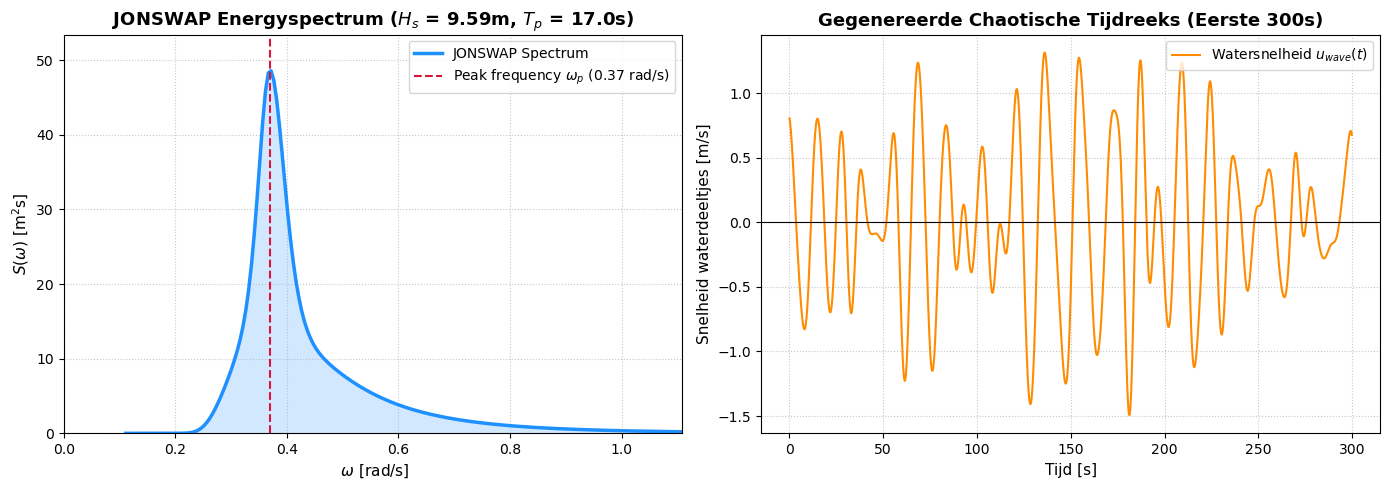

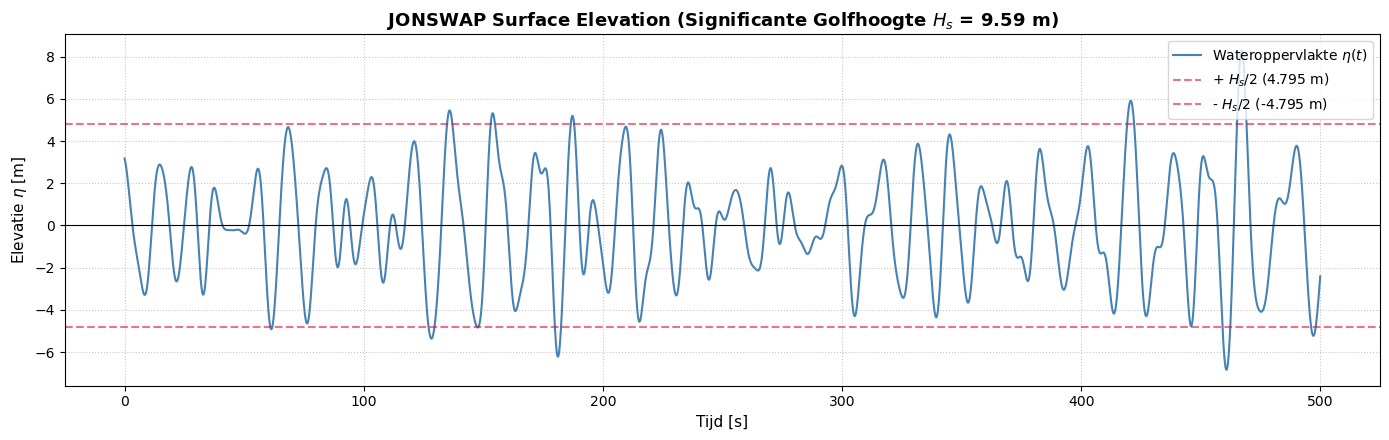

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scpi
from scipy.interpolate import interp1d


rho_w = 1025.0       
U = 1.44             
H_s = 9.59          
T_p = 17.0           
z_axis = 25.0        
D_out = 20.0         
dist_c2c = 30.0      
C_d = 0.75           
C_m_coef = 2.0       
h = 54.0             
zeta = 0.05    

g = 9.81
t_sim = 1000.0                     
t_eval = np.arange(500, t_sim, 0.1)

C_s = 1.0 - 2.0 * 0.95 * np.sqrt((C_d * D_out) / (dist_c2c + 6.0 * D_out))


omega_p = (2 * np.pi) / T_p
gamma = 3.3  

N_freq = 200
omega = np.linspace(0.3 * omega_p, 3.0 * omega_p, N_freq)
d_omega = omega[1] - omega[0]

sigma = np.where(omega <= omega_p, 0.07, 0.09)
A = np.exp(-1.25 * (omega_p / omega)**4)
B = np.exp(-0.5 * ((omega - omega_p) / (sigma * omega_p))**2)
S_unscaled = (g**2 / omega**5) * A * (gamma**B)

m0_unscaled = np.trapezoid(S_unscaled, omega)
schaalfactor = (H_s / 4)**2 / m0_unscaled
S_omega = S_unscaled * schaalfactor

a_i = np.sqrt(2 * S_omega * d_omega)
np.random.seed(42)  
fase_i = np.random.uniform(0, 2 * np.pi, N_freq)
k_i = (omega**2) / g 

t_pre = np.linspace(0, t_sim + 10, int((t_sim + 10) * 10)) 
u_wave_pre = np.zeros_like(t_pre)
a_wave_pre = np.zeros_like(t_pre)

t_pre = np.linspace(0, t_sim + 10, int((t_sim + 10) * 10)) 
u_wave_pre = np.zeros_like(t_pre)
a_wave_pre = np.zeros_like(t_pre)

for i in range(N_freq):
    fase_t = omega[i] * t_pre + fase_i[i]
    verval_factor = np.exp(-k_i[i] * z_axis)
    
    u_wave_pre += a_i[i] * omega[i] * verval_factor * np.cos(fase_t)
    a_wave_pre -= a_i[i] * (omega[i]**2) * verval_factor * np.sin(fase_t)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ax1.plot(omega, S_omega, color='dodgerblue', linewidth=2.5, label='JONSWAP Spectrum')
# ax1.axvline(omega_p, color='crimson', linestyle='--', label=f'Peak frequency $\omega_p$ ({omega_p:.2f} rad/s)')
# ax1.fill_between(omega, 0, S_omega, color='dodgerblue', alpha=0.2)

# ax1.set_title(f"JONSWAP Energyspectrum ($H_s$ = {H_s}m, $T_p$ = {T_p}s)", fontsize=13, fontweight='bold')
# ax1.set_xlabel(r" $\omega$ [rad/s]", fontsize=11)
# ax1.set_ylabel(r"$S(\omega)$ [m$^2$s]", fontsize=11)
# ax1.set_xlim(0, max(omega))
# ax1.set_ylim(0, max(S_omega) * 1.1)
# ax1.grid(True, linestyle=':', alpha=0.7)
# ax1.legend()

# mask = t_pre <= 300
# ax2.plot(t_pre[mask], u_wave_pre[mask], color='darkorange', linewidth=1.5, label='Watersnelheid $u_{wave}(t)$')

# ax2.set_title("Gegenereerde Chaotische Tijdreeks (Eerste 300s)", fontsize=13, fontweight='bold')
# ax2.set_xlabel("Tijd [s]", fontsize=11)
# ax2.set_ylabel("Snelheid waterdeeltjes [m/s]", fontsize=11)
# ax2.axhline(0, color='black', linewidth=0.8)
# ax2.grid(True, linestyle=':', alpha=0.7)
# ax2.legend(loc='upper right')

# plt.tight_layout()
# plt.show()

# eta_pre = np.zeros_like(t_pre)

# for i in range(N_freq):
#     fase_t = omega[i] * t_pre + fase_i[i]
#     eta_pre += a_i[i] * np.cos(fase_t)

# plt.figure(figsize=(14, 4.5))

# mask_eta = t_pre <= 500

# plt.plot(t_pre[mask_eta], eta_pre[mask_eta], color='steelblue', linewidth=1.5, label='Wateroppervlakte $\eta(t)$')

# plt.axhline(H_s / 2, color='crimson', linestyle='--', alpha=0.6, label=f'+ $H_s/2$ ({H_s/2} m)')
# plt.axhline(-H_s / 2, color='crimson', linestyle='--', alpha=0.6, label=f'- $H_s/2$ ({-H_s/2} m)')

# # 
# plt.title(f"JONSWAP Surface Elevation (Significante Golfhoogte $H_s$ = {H_s} m)", fontsize=13, fontweight='bold')
# plt.xlabel("Tijd [s]", fontsize=11)
# plt.ylabel("Elevatie $\eta$ [m]", fontsize=11)
# plt.axhline(0, color='black', linewidth=0.8) 
# plt.grid(True, linestyle=':', alpha=0.7)

# plt.legend(loc='upper right')
# plt.tight_layout()

# plt.show()

u_wave_interp = interp1d(t_pre, u_wave_pre, kind='cubic')
a_wave_interp = interp1d(t_pre, a_wave_pre, kind='cubic')


In [ ]:
gekozen_modes_idx = []
nMode = 7999
print(f"--- START SOLVER MET {nMode} GEKOZEN MODES ---")

PHI = vr[:, :nMode]
f_gekozen = f[:nMode]
M_FF_np = np.array(M_FF)

Mm = np.zeros(nMode)
Km = np.zeros(nMode)
Cm = np.zeros(nMode)

for i in range(nMode):
    omega_i = 2 * np.pi * f_gekozen[i]
    print(f"  > Mode {i}: Freq = {f_gekozen[i]:.3f} Hz ingeladen.")
    Mm[i] = np.dot(PHI[:, i].T, np.dot(M_FF_np, PHI[:, i]))
    Km[i] = (omega_i**2) * Mm[i]
    Cm[i] = 2 * zeta * omega_i * Mm[i]


ruimtelijke_kracht_verdeling = np.zeros(len(DofsF))
for idx, dof in enumerate(DofsF):
    if dof % LDOF == 1: 
        ruimtelijke_kracht_verdeling[idx] = 1.0 if dof < (nDof // 2) else C_s

def P_modaal(t, Vm):
    u_wave_t = u_wave_interp(t)
    a_wave_t = a_wave_interp(t)
    
    V_fysiek = PHI @ Vm 
    
    u_rel = (U + u_wave_t) - V_fysiek
    
    F_drag = 0.5 * rho_w * C_d * D_out * u_rel * np.abs(u_rel)
    F_inertia = rho_w * C_m_coef * (np.pi * (D_out**2) / 4) * a_wave_t
    
    F_fysiek = (F_drag + F_inertia) * h * ruimtelijke_kracht_verdeling
    
    return PHI.T @ F_fysiek

def qdot(t, q):
    Um = q[0:nMode]          
    Vm = q[nMode:2*nMode]    
    Am = (P_modaal(t, Vm) - (Km * Um + Cm * Vm)) / Mm
    return np.append(Vm, Am)

q0 = np.zeros(2 * nMode)          

sol = scpi.solve_ivp(fun=qdot, y0=q0, t_span=[0, t_sim], t_eval=t_eval, method='Radau', rtol=1e-4, atol=1e-6)
print(f"Jacobian evaluations (njev): {sol.njev}")


--- START SOLVER MET 7999 GEKOZEN MODES ---
  > Mode 0: Freq = 0.000 Hz ingeladen.
  > Mode 1: Freq = 0.000 Hz ingeladen.
  > Mode 2: Freq = 0.000 Hz ingeladen.
  > Mode 3: Freq = 0.000 Hz ingeladen.
  > Mode 4: Freq = 0.000 Hz ingeladen.
  > Mode 5: Freq = 0.000 Hz ingeladen.
  > Mode 6: Freq = 0.000 Hz ingeladen.
  > Mode 7: Freq = 0.000 Hz ingeladen.
  > Mode 8: Freq = 0.000 Hz ingeladen.
  > Mode 9: Freq = 0.000 Hz ingeladen.
  > Mode 10: Freq = 0.000 Hz ingeladen.
  > Mode 11: Freq = 0.000 Hz ingeladen.
  > Mode 12: Freq = 0.000 Hz ingeladen.
  > Mode 13: Freq = 0.000 Hz ingeladen.
  > Mode 14: Freq = 0.001 Hz ingeladen.
  > Mode 15: Freq = 0.001 Hz ingeladen.
  > Mode 16: Freq = 0.001 Hz ingeladen.
  > Mode 17: Freq = 0.001 Hz ingeladen.
  > Mode 18: Freq = 0.001 Hz ingeladen.
  > Mode 19: Freq = 0.001 Hz ingeladen.
  > Mode 20: Freq = 0.001 Hz ingeladen.
  > Mode 21: Freq = 0.001 Hz ingeladen.
  > Mode 22: Freq = 0.001 Hz ingeladen.
  > Mode 23: Freq = 0.001 Hz ingeladen.
  > Mo